In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('/content/advertising.csv')

df.head()

,Unnamed: 0,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales ($)
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [4]:
print("Shape of dataset:", df.shape)
df.info()

Shape of dataset: (200, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unnamed: 0               200 non-null    int64  
 1   TV Ad Budget ($)         200 non-null    float64
 2   Radio Ad Budget ($)      200 non-null    float64
 3   Newspaper Ad Budget ($)  200 non-null    float64
 4   Sales ($)                200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [5]:
df.describe()

,Unnamed: 0,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales ($)
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


In [6]:
df.isnull().sum()

,0
Unnamed: 0,0
TV Ad Budget ($),0
Radio Ad Budget ($),0
Newspaper Ad Budget ($),0
Sales ($),0


In [7]:
df.duplicated().sum()

np.int64(0)

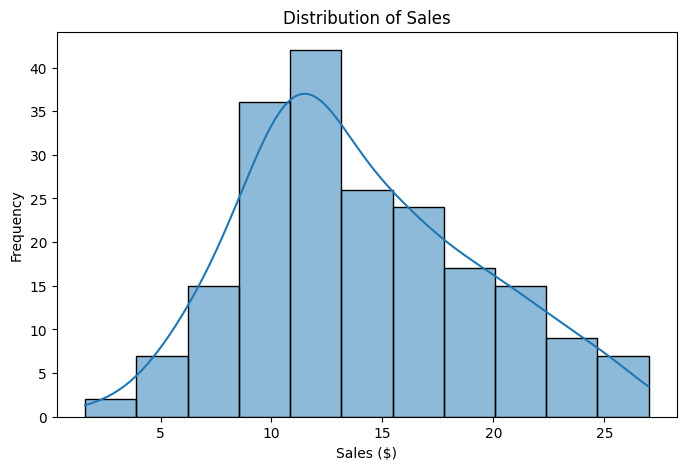

In [9]:
## 2. Exploratory Data Analysis

plt.figure(figsize=(8, 5))

sns.histplot(df['Sales ($)'], kde=True)

plt.title('Distribution of Sales')
plt.xlabel('Sales ($)')
plt.ylabel('Frequency')

plt.show()

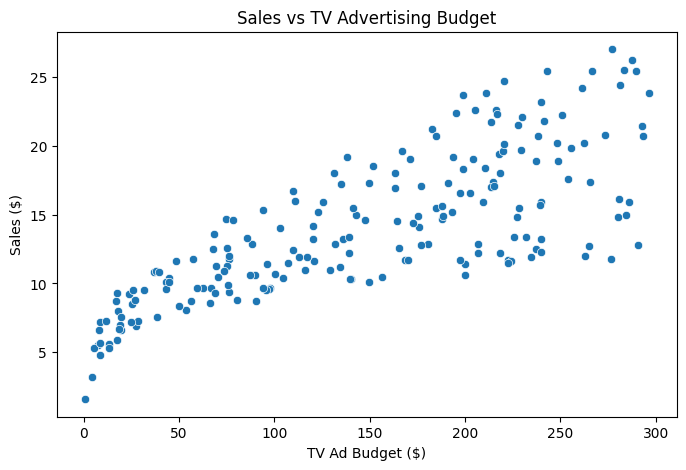

In [10]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='TV Ad Budget ($)',
    y='Sales ($)'
)

plt.title('Sales vs TV Advertising Budget')
plt.xlabel('TV Ad Budget ($)')
plt.ylabel('Sales ($)')

plt.show()

In [11]:
df = df.drop(columns=['Unnamed: 0'])

In [12]:
df.head()

,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales ($)
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


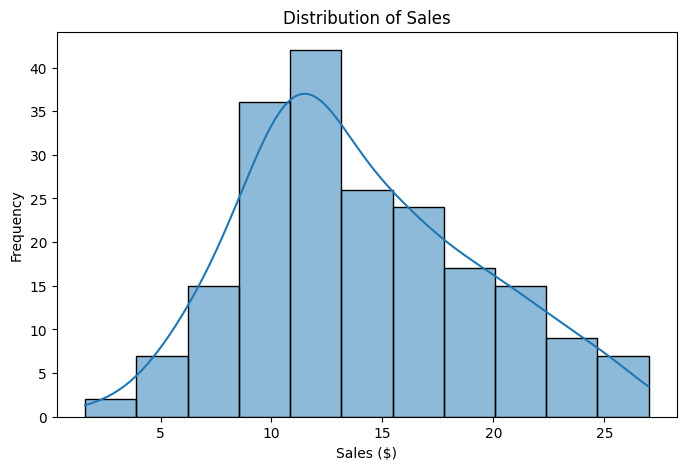

In [13]:
plt.figure(figsize=(8, 5))

sns.histplot(df['Sales ($)'], kde=True)

plt.title('Distribution of Sales')
plt.xlabel('Sales ($)')
plt.ylabel('Frequency')

plt.show()

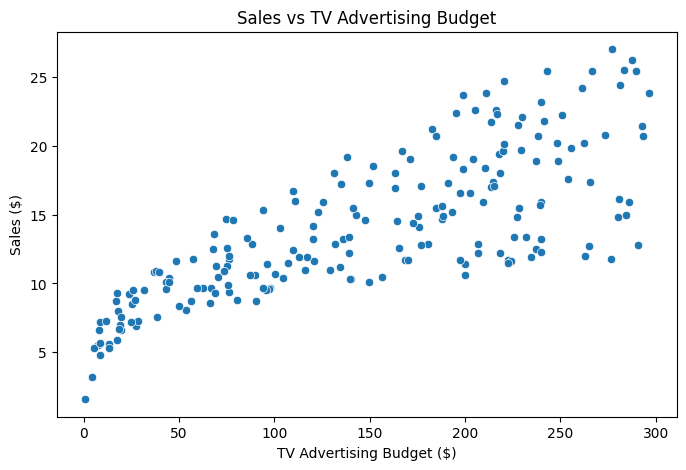

In [14]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='TV Ad Budget ($)',
    y='Sales ($)'
)

plt.title('Sales vs TV Advertising Budget')
plt.xlabel('TV Advertising Budget ($)')
plt.ylabel('Sales ($)')

plt.show()

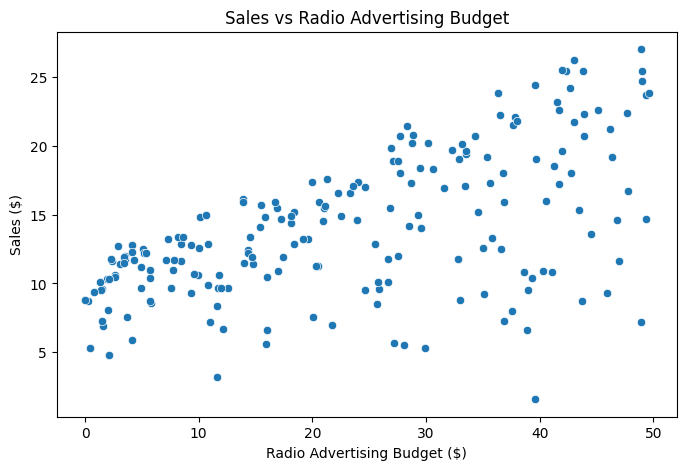

In [15]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='Radio Ad Budget ($)',
    y='Sales ($)'
)

plt.title('Sales vs Radio Advertising Budget')
plt.xlabel('Radio Advertising Budget ($)')
plt.ylabel('Sales ($)')

plt.show()

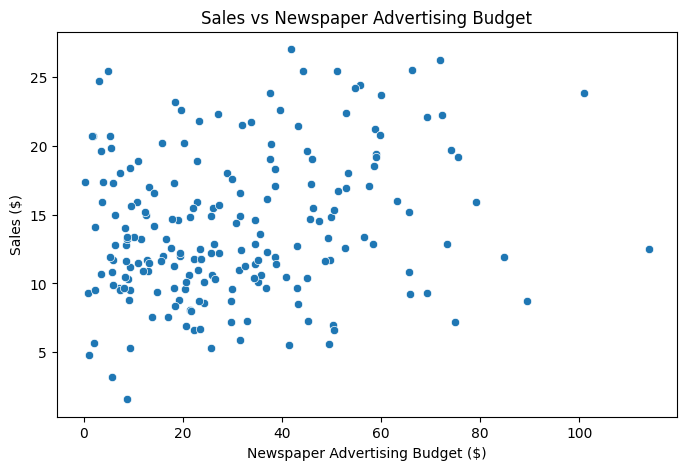

In [16]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='Newspaper Ad Budget ($)',
    y='Sales ($)'
)

plt.title('Sales vs Newspaper Advertising Budget')
plt.xlabel('Newspaper Advertising Budget ($)')
plt.ylabel('Sales ($)')

plt.show()

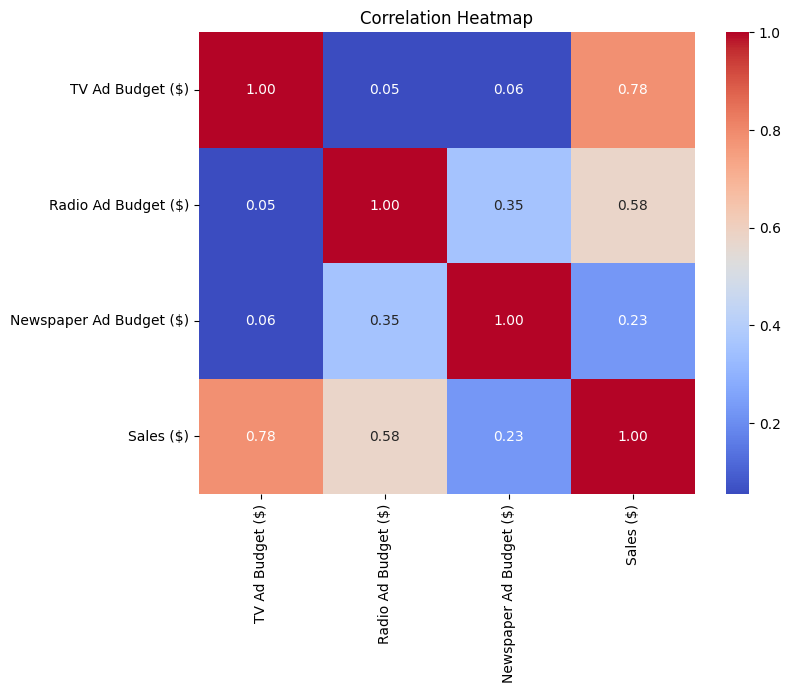

In [17]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    df.corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

In [18]:
X = df[
    [
        'TV Ad Budget ($)',
        'Radio Ad Budget ($)',
        'Newspaper Ad Budget ($)'
    ]
]

y = df['Sales ($)']
print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   TV Ad Budget ($)  Radio Ad Budget ($)  Newspaper Ad Budget ($)
0             230.1                 37.8                     69.2
1              44.5                 39.3                     45.1
2              17.2                 45.9                     69.3
3             151.5                 41.3                     58.5
4             180.8                 10.8                     58.4

Target:
0    22.1
1    10.4
2     9.3
3    18.5
4    12.9
Name: Sales ($), dtype: float64


In [19]:
## 4. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 160
Testing samples: 40


In [20]:

## 5. Linear Regression
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)
y_pred_linear = linear_model.predict(X_test)

In [21]:
mae_linear = mean_absolute_error(
    y_test,
    y_pred_linear
)

rmse_linear = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_linear
    )
)

r2_linear = r2_score(
    y_test,
    y_pred_linear
)

print("Linear Regression Results")
print("-------------------------")
print("MAE :", mae_linear)
print("RMSE:", rmse_linear)
print("R²  :", r2_linear)


Linear Regression Results
-------------------------
MAE : 1.4607567168117603
RMSE: 1.78159966153345
R²  : 0.899438024100912


In [22]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': linear_model.coef_
})

coefficients
print("Intercept:", linear_model.intercept_)

Intercept: 2.979067338122629


In [23]:
## 6. Random Forest Regression
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)


In [24]:
mae_rf = mean_absolute_error(
    y_test,
    y_pred_rf
)

rmse_rf = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_rf
    )
)

r2_rf = r2_score(
    y_test,
    y_pred_rf
)

print("Random Forest Regression Results")
print("--------------------------------")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

Random Forest Regression Results
--------------------------------
MAE : 0.6287125000000021
RMSE: 0.7572349907723515
R²  : 0.9818333477552758


In [25]:
results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest Regression'
    ],

    'MAE': [
        mae_linear,
        mae_rf
    ],

    'RMSE': [
        rmse_linear,
        rmse_rf
    ],

    'R2 Score': [
        r2_linear,
        r2_rf
    ]
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,1.460757,1.781600,0.899438
1,Random Forest Regression,0.628713,0.757235,0.981833


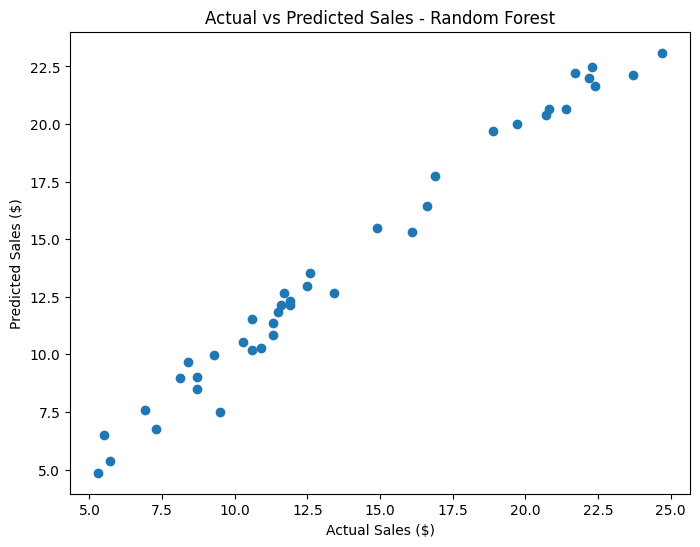

In [26]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_rf
)

plt.xlabel('Actual Sales ($)')
plt.ylabel('Predicted Sales ($)')
plt.title('Actual vs Predicted Sales - Random Forest')

plt.show()

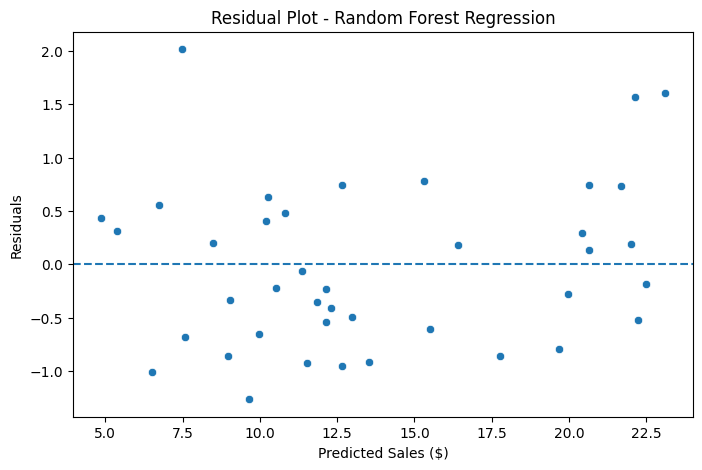

In [27]:
residuals = y_test - y_pred_rf
plt.figure(figsize=(8, 5))

sns.scatterplot(
    x=y_pred_rf,
    y=residuals
)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.title('Residual Plot - Random Forest Regression')
plt.xlabel('Predicted Sales ($)')
plt.ylabel('Residuals')

plt.show()

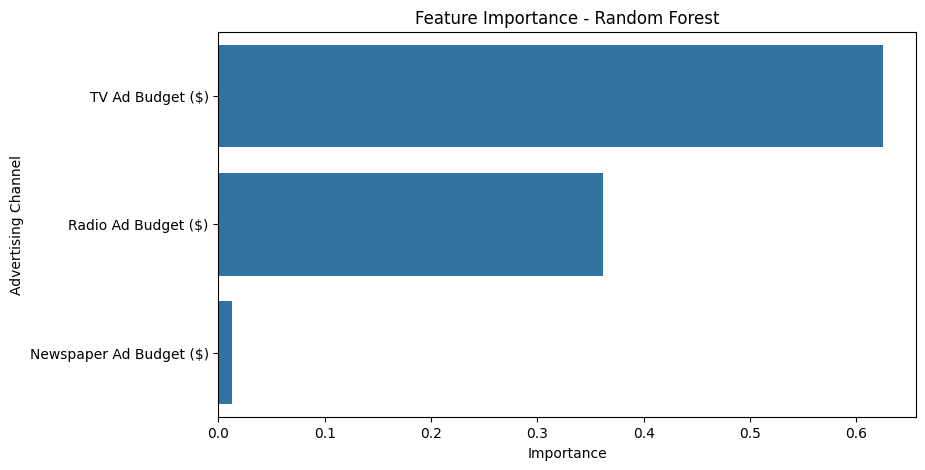

In [28]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance
plt.figure(figsize=(9, 5))

sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature'
)

plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance')
plt.ylabel('Advertising Channel')

plt.show()

In [29]:
most_important = feature_importance.iloc[0]

print(
    "Most important advertising channel:",
    most_important['Feature']
)

print(
    "Importance:",
    most_important['Importance']
)

Most important advertising channel: TV Ad Budget ($)
Importance: 0.6247274604702653


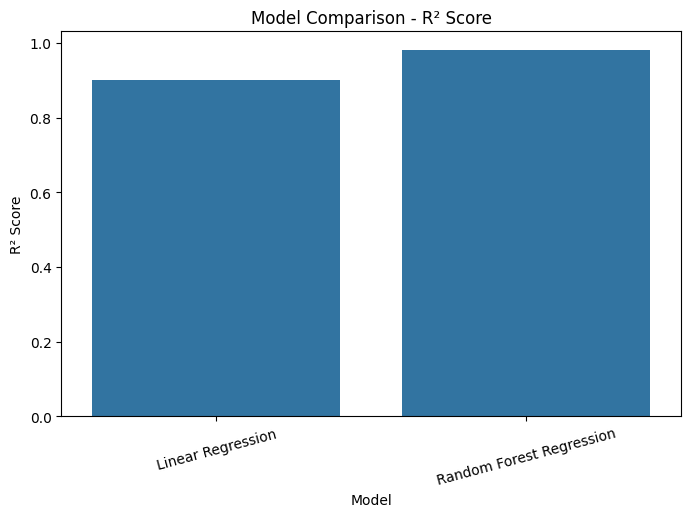

In [30]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=results,
    x='Model',
    y='R2 Score'
)

plt.title('Model Comparison - R² Score')
plt.xlabel('Model')
plt.ylabel('R² Score')

plt.xticks(rotation=15)

plt.show()